# T2: Seasonality & Promotion Diagnostics

**Timeline**: 12 Feb – 24 Feb

## Objectives
- Quantify promotion prevalence (marginal/joint activation of promo_type_*)
- Summarize promotion intensities (promo_value_*) and confounding risk
- Analyze calendar effects (day-of-week, month; holiday markers) 
- Compare promotional vs non-promotional periods

In [1]:
# Import Required Libraries
import pyarrow.feather as feather
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load Data
table = feather.read_table('../dataset/data_andre.feather', memory_map=True)
df = table.to_pandas()

# Clean and prepare dates
df['date'] = pd.to_datetime(df['date']).dt.normalize()
df = df.sort_values(['store_id', 'item_id', 'date']).reset_index(drop=True)

print(f"Data shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Total days: {(df['date'].max() - df['date'].min()).days + 1}")
df.head()

Data shape: (1082371, 24)

Columns: ['date', 'item_id', 'value', 'cat_label', 'sdep_label', 'dep_label', 'dmn_label', 'promo_type_FRPG', 'promo_value_FRPG', 'promo_type_GAS', 'promo_value_GAS', 'promo_type_BOGO', 'promo_value_BOGO', 'promo_type_DISC', 'promo_value_DISC', 'promo_type_CIRC', 'promo_value_CIRC', 'promo_type_CIRE', 'promo_value_CIRE', 'promo_type_CLCP', 'promo_value_CLCP', 'promo_type_LFPE', 'promo_value_LFPE', 'store_id']

Date range: 2021-01-23 to 2023-02-22
Total days: 761


,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
0,2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
1,2021-01-24,27,14,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
2,2021-01-25,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
3,2021-01-26,27,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
4,2021-01-27,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269


## 1. Promotion Prevalence Analysis

### Marginal Activation Rates
Analyze the proportion of records where each promotion type is active.

In [3]:
# 1.1 Identify promotion columns
promo_cols = [col for col in df.columns if col.startswith('promo_type_')]
promo_value_cols = [col for col in df.columns if col.startswith('promo_value_')]

print(f"Promotion type columns: {promo_cols}")
print(f"Promotion value columns: {promo_value_cols}")
print()

# 1.2 Marginal activation rates
print("=" * 70)
print("MARGINAL ACTIVATION RATES (% of records where promo is active)")
print("=" * 70)

marginal_rates = {}
for col in promo_cols:
    # Activation = current month has active promotion (value > 0)
    active_count = (df[col] > 0).sum()
    total_count = len(df)
    rate = active_count / total_count * 100
    marginal_rates[col] = rate
    print(f"{col:20s}: {active_count:8d} / {total_count:8d} = {rate:6.2f}%")

print()

Promotion type columns: ['promo_type_FRPG', 'promo_type_GAS', 'promo_type_BOGO', 'promo_type_DISC', 'promo_type_CIRC', 'promo_type_CIRE', 'promo_type_CLCP', 'promo_type_LFPE']
Promotion value columns: ['promo_value_FRPG', 'promo_value_GAS', 'promo_value_BOGO', 'promo_value_DISC', 'promo_value_CIRC', 'promo_value_CIRE', 'promo_value_CLCP', 'promo_value_LFPE']

MARGINAL ACTIVATION RATES (% of records where promo is active)
promo_type_FRPG     :    22442 /  1082371 =   2.07%
promo_type_GAS      :     8792 /  1082371 =   0.81%
promo_type_BOGO     :     8201 /  1082371 =   0.76%
promo_type_DISC     :    93072 /  1082371 =   8.60%
promo_type_CIRC     :    98190 /  1082371 =   9.07%
promo_type_CIRE     :    29434 /  1082371 =   2.72%
promo_type_CLCP     :     3481 /  1082371 =   0.32%
promo_type_LFPE     :    14341 /  1082371 =   1.32%



In [6]:
# 1.3 Joint activation rates (combinations of promos)
print("=" * 70)
print("JOINT ACTIVATION RATES (co-occurrence of promotions)")
print("=" * 70)

# Create binary indicator matrix
promo_binary = (df[promo_cols] > 0).astype(int)

# Count no promotions vs. at least one promotion
no_promo = (promo_binary.sum(axis=1) == 0).sum()
any_promo = (promo_binary.sum(axis=1) > 0).sum()

print(f"No promotions:      {no_promo:8d} ({no_promo/len(df)*100:6.2f}%)")
print(f"At least 1 promo:   {any_promo:8d} ({any_promo/len(df)*100:6.2f}%)")
print()

# Count by number of simultaneous promotions
print("Distribution by number of simultaneous promotions:")
for n_promos in range(len(promo_cols) + 1):
    count = (promo_binary.sum(axis=1) == n_promos).sum()
    pct = count / len(df) * 100
    print(f"  {n_promos} promotions: {count:8d} ({pct:6.2f}%)")

print()

# Count by combination of simultaneous promotions
for i in range(len(promo_cols)):
    for j in range(i + 1, len(promo_cols)):
        col1, col2 = promo_cols[i], promo_cols[j]
        count = ((promo_binary[col1] > 0) & (promo_binary[col2] > 0)).sum()
        pct = count / len(df) * 100
        print(f"  {col1} + {col2}: {count:8d} ({pct:6.2f}%)")

JOINT ACTIVATION RATES (co-occurrence of promotions)
No promotions:        819448 ( 75.71%)
At least 1 promo:     262923 ( 24.29%)

Distribution by number of simultaneous promotions:
  0 promotions:   819448 ( 75.71%)
  1 promotions:   248391 ( 22.95%)
  2 promotions:    14034 (  1.30%)
  3 promotions:      498 (  0.05%)
  4 promotions:        0 (  0.00%)
  5 promotions:        0 (  0.00%)
  6 promotions:        0 (  0.00%)
  7 promotions:        0 (  0.00%)
  8 promotions:        0 (  0.00%)

  promo_type_FRPG + promo_type_GAS:        0 (  0.00%)
  promo_type_FRPG + promo_type_BOGO:        9 (  0.00%)
  promo_type_FRPG + promo_type_DISC:     1320 (  0.12%)
  promo_type_FRPG + promo_type_CIRC:      174 (  0.02%)
  promo_type_FRPG + promo_type_CIRE:       14 (  0.00%)
  promo_type_FRPG + promo_type_CLCP:        0 (  0.00%)
  promo_type_FRPG + promo_type_LFPE:      115 (  0.01%)
  promo_type_GAS + promo_type_BOGO:        0 (  0.00%)
  promo_type_GAS + promo_type_DISC:      174 (  0.02%)


## 2. Promotion Intensities & Confounding Risk

### Promotion Value Statistics
Analyze the magnitude of promotions when active.

CORRELATIONS BETWEEN PROMOTION TYPES (confounding risk)



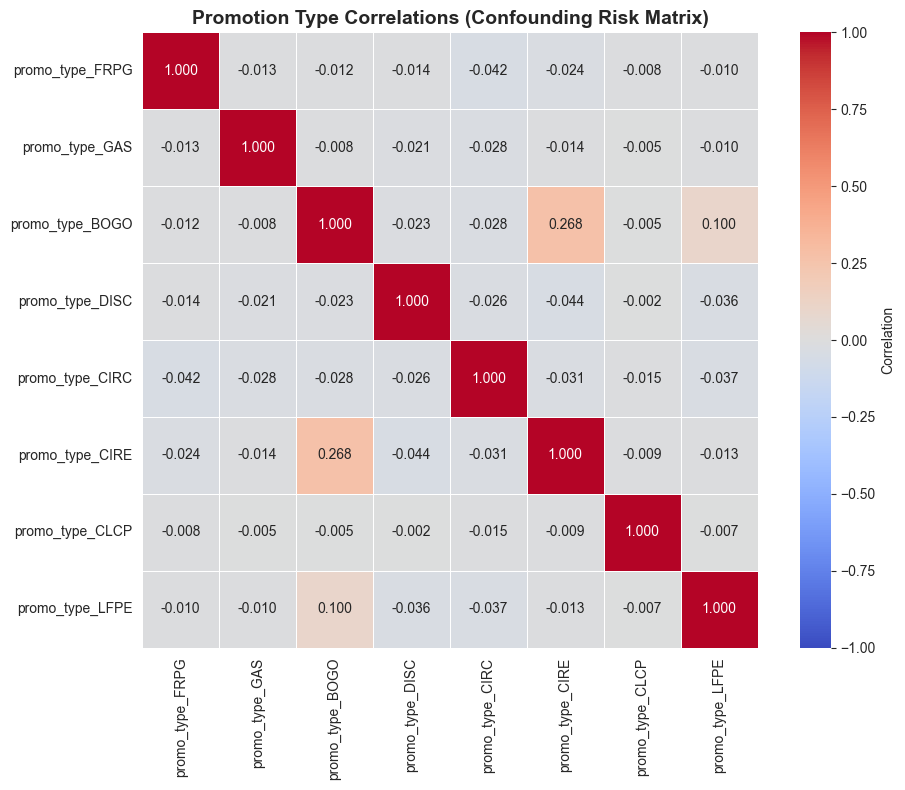

In [ ]:


corr_matrix = promo_binary.corr()
# 2.3 Heatmap of promotion type correlations
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Promotion Type Correlations (Confounding Risk Matrix)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show();

## 3. Calendar Effects Analysis

### Extract Calendar Features
Analyze temporal patterns: day-of-week, month, and seasonal effects.

In [8]:
# 3.1 Extract calendar features
df['day_of_week'] = df['date'].dt.day_name()
df['week_of_year'] = df['date'].dt.isocalendar().week
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%B')
df['quarter'] = df['date'].dt.quarter
df['day_of_month'] = df['date'].dt.day

print("=" * 70)
print("CALENDAR FEATURES - DISTRIBUTION")
print("=" * 70)
print(f"\nDay-of-week distribution:")
print(df['day_of_week'].value_counts().sort_index())
print(f"\nMonth distribution:")
print(df['month_name'].value_counts().sort_index(ascending=False))

# 3.2 Average metrics by day-of-week
print("\n" + "=" * 70)
print("PROMOTION PREVALENCE BY DAY-OF-WEEK")
print("=" * 70)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = df.groupby('day_of_week')[promo_cols].apply(lambda x: (x > 0).mean() * 100)
dow_stats = dow_stats.reindex(day_order)
print(dow_stats.round(2))

# 3.3 Average metrics by month
print("\n" + "=" * 70)
print("PROMOTION PREVALENCE BY MONTH")
print("=" * 70)

month_stats = df.groupby('month_name')[promo_cols].apply(lambda x: (x > 0).mean() * 100)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_stats = month_stats.reindex(month_order)
print(month_stats.round(2))

print()

CALENDAR FEATURES - DISTRIBUTION

Day-of-week distribution:
day_of_week
Friday       153729
Monday       155061
Saturday     154986
Sunday       155081
Thursday     153727
Tuesday      154999
Wednesday    154788
Name: count, dtype: int64

Month distribution:
month_name
September     85469
October       88288
November      85435
May           88474
March         88314
June          85620
July          88474
January      100418
February     109616
December      88226
August        88444
April         85593
Name: count, dtype: int64

PROMOTION PREVALENCE BY DAY-OF-WEEK
             promo_type_FRPG  promo_type_GAS  promo_type_BOGO  \
day_of_week                                                     
Monday                  2.03            0.81             0.74   
Tuesday                 2.02            0.80             0.75   
Wednesday               2.02            0.78             0.74   
Thursday                2.01            0.78             0.75   
Friday                  2.13         

## 4. Promo vs Non-Promo Comparisons

### Segment Data and Compare Metrics

In [11]:
# 4.1 Create promo segments
any_promo_flag = (promo_binary.sum(axis=1) > 0)
df['has_promotion'] = any_promo_flag

# 4.2 Compare sales value
print("=" * 70)
print("SALES COMPARISON: PROMOTIONAL vs NON-PROMOTIONAL PERIODS")
print("=" * 70)
print()

promo_sales = df[df['has_promotion']]['value']
no_promo_sales = df[~df['has_promotion']]['value']

print("Promotional periods (any promo active):")
print(f"  Mean sales:   {promo_sales.mean():.2f}")
print(f"  Median sales: {promo_sales.median():.2f}")
print(f"  Std dev:      {promo_sales.std():.2f}")
print(f"  N records:    {len(promo_sales)}")
print()

print("Non-promotional periods (no promo active):")
print(f"  Mean sales:   {no_promo_sales.mean():.2f}")
print(f"  Median sales: {no_promo_sales.median():.2f}")
print(f"  Std dev:      {no_promo_sales.std():.2f}")
print(f"  N records:    {len(no_promo_sales)}")
print()

# T-test for significant difference
t_stat, p_value = ttest_ind(promo_sales, no_promo_sales)
print(f"T-test: t={t_stat:.4f}, p={p_value:.4e}")
print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")
print()

# 4.3 Compare by promotion type
print("=" * 70)
print("SALES IMPACT BY INDIVIDUAL PROMOTION TYPE")
print("=" * 70)
print()

for col in promo_cols:
    active_sales = df[df[col] > 0]['value']
    inactive_sales = df[df[col] == 0]['value']
    
    t_stat, p_value = ttest_ind(active_sales, inactive_sales)
    
    print(f"{col}:")
    print(f"  Active:   mean={active_sales.mean():.2f} (n={len(active_sales)})")
    print(f"  Inactive: mean={inactive_sales.mean():.2f} (n={len(inactive_sales)})")
    print(f"  Difference: {active_sales.mean() - inactive_sales.mean():.2f}")
    print(f"  P-value: {p_value:.4e} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")
    print()

print()

SALES COMPARISON: PROMOTIONAL vs NON-PROMOTIONAL PERIODS

Promotional periods (any promo active):
  Mean sales:   9.00
  Median sales: 6.00
  Std dev:      13.08
  N records:    262923

Non-promotional periods (no promo active):
  Mean sales:   5.55
  Median sales: 3.00
  Std dev:      10.56
  N records:    819448

T-test: t=137.1981, p=0.0000e+00
Significant difference: Yes

SALES IMPACT BY INDIVIDUAL PROMOTION TYPE

promo_type_FRPG:
  Active:   mean=12.75 (n=22442)
  Inactive: mean=6.25 (n=1059929)
  Difference: 6.50
  P-value: 0.0000e+00 ***

promo_type_GAS:
  Active:   mean=8.81 (n=8792)
  Inactive: mean=6.37 (n=1073579)
  Difference: 2.44
  P-value: 5.4178e-90 ***

promo_type_BOGO:
  Active:   mean=8.46 (n=8201)
  Inactive: mean=6.37 (n=1074170)
  Difference: 2.08
  P-value: 6.1050e-62 ***

promo_type_DISC:
  Active:   mean=6.74 (n=93072)
  Inactive: mean=6.35 (n=989299)
  Difference: 0.39
  P-value: 1.3721e-23 ***

promo_type_CIRC:
  Active:   mean=9.43 (n=98190)
  Inactive: mean